# Titan Dataset Exploratory Data Analysis
_00_eda.ipynb_

## Description

The goal of this notebook is to perform an initial exploratory data analysis on the Kaggle Titanic training dataset. We will profile the data, identify missing values, and analyze the relationship between key passenger features (like class, sex, and age) and their survival rates.

Source Data: [Kaggle Titanic Machine Learning from Disaster](https://www.kaggle.com/c/titanic/data)

## Imports

In [1]:
## System imports
import warnings

In [3]:
# Third-party imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Settings and Parameters

In [7]:
# train data path
TRAIN_DATA_PATH = "../data/train.csv"

In [8]:
# pandas settings
pd.set_option("display.max_columns", None)

In [9]:
# matplotlib and seaborn settings
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

## Functions

In [10]:
def summarize_missing_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the count and percentage of missing values in a DataFrame.

    Args:
        df (pd.DataFrame): The input pandas DataFrame to analyze.

    Returns:
        pd.DataFrame: A summary table of columns containing missing values, 
                      sorted by the highest count of missing data.
    """
    missing_counts = df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0]
    missing_percent = (missing_counts / len(df)) * 100
    
    summary_df = pd.DataFrame({
        'Missing Count': missing_counts,
        'Percentage (%)': missing_percent
    }).sort_values(by='Missing Count', ascending=False)
    
    return summary_df

## Execution

### Data loading and high-level data profiling
Load the data and look at the basic structure and data types.

In [11]:
df = pd.read_csv(TRAIN_DATA_PATH)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Missing Values Assessment
We need to understand which features are incomplete before deciding on imputation strategies for our machine learning model.

In [13]:
summarize_missing_data(df)

,Missing Count,Percentage (%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


**Observation:** `Cabin` is missing for roughly 77% of passengers, making it highly sparse. `Age` is missing for about 20% of passengers and will require imputation. `Embarked` is only missing two values, which can easily be filled with the mode.

### Target Variable Distribution
Let's look at the baseline survival rate.

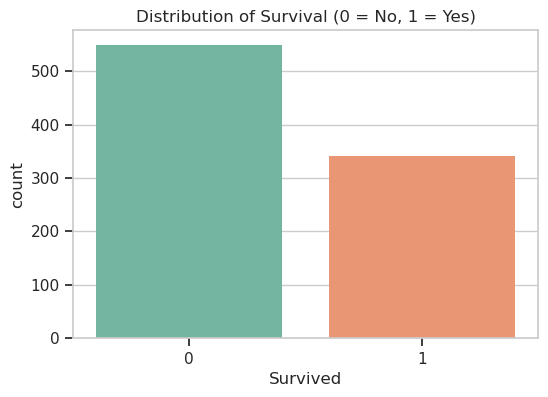

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived", palette="Set2")
plt.title("Distribution of Survival (0 = No, 1 = Yes)")
plt.show()

### Feature Analysis: Sex and Passenger Class
Historically, "women and children first" was the protocol on the Titanic. Let's see how `Sex` and `Pclass` (a proxy for socio-economic status) impacted survival.

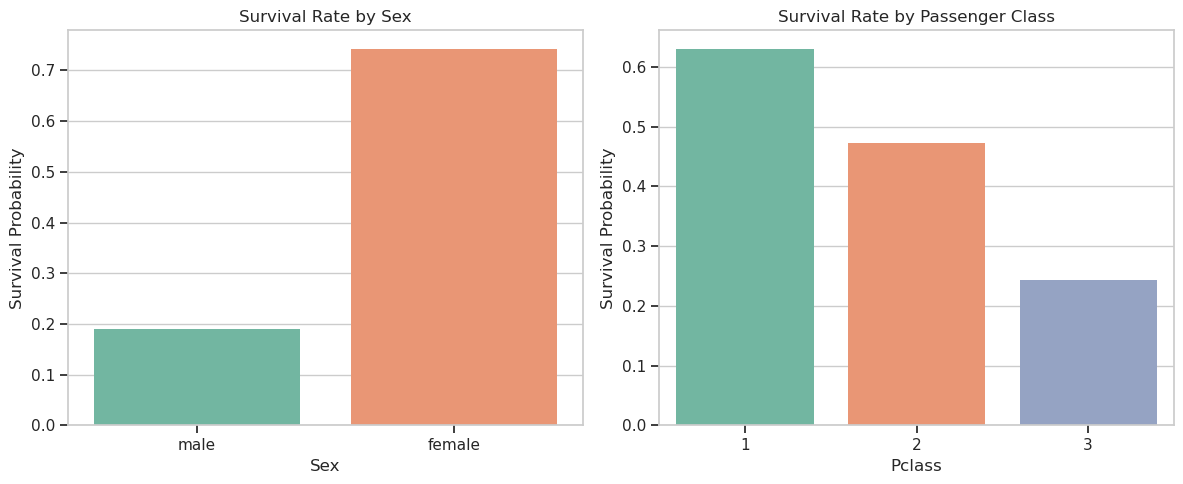

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Survival by Sex
sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0], palette="Set2", errorbar=None)
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Probability")

# Survival by Pclass
sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], palette="Set2", errorbar=None)
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Probability")

plt.tight_layout()
plt.show()

**Observation:** Females had a drastically higher survival rate than males. First-class passengers had the highest survival rate, while third-class had the lowest.

### Feature Analysis: Age Distribution
Let's examine how the age of passengers relates to their survival.

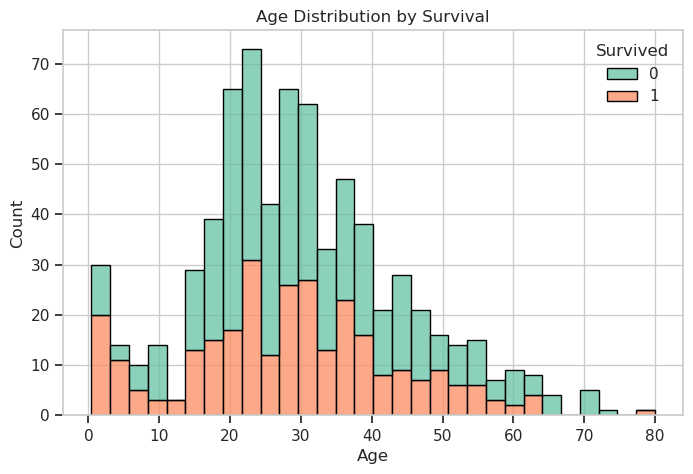

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=30, palette="Set2")
plt.title("Age Distribution by Survival")
plt.show()

## Conclusion

Based on this initial profiling, we can establish a few key takeaways for the modeling phase:

* **Imputation is necessary:** The `Age` feature has missing values that must be imputed (potentially using the median age or grouping by `Pclass` and `Sex`). `Embarked` can be filled with the most frequent port.
* **Drop or engineer `Cabin`:** With 77% missing data, `Cabin` should either be dropped or engineered into a binary feature (e.g., `Has_Cabin`).
* **Strong Predictors:** `Sex` and `Pclass` exhibit distinct survival boundaries and will be critical features for the classifier (like Logistic Regression or CatBoost).